# 🔄 Notebook 5: Monitoring & Learning Agent
**Project**: Agentic AI-Based Dynamic Tariff Optimization for EV Charging Networks  
**Team**: Socbiz Analytics | OP'26  

---

## Overview
The Monitoring & Learning Agent evaluates each pricing decision against real outcomes and **iteratively refines policy parameters** through a feedback loop.

### Metrics Evaluated per Episode (= 1 day)
| Metric | Description |
|--------|-------------|
| `Revenue Gain %` | (Dynamic − Fixed) / Fixed × 100 |
| `Pricing Efficiency Score` | Revenue / kWh delivered |
| `Queue Proxy Reduction` | Δ in congestion queue length proxy |
| `Off-Peak Uplift %` | Change in off-peak session volume |
| `Customer Response Rate` | Demand shift % per % price change |

### Policy Update Rules (Feedback Loop)
- If `Revenue Gain % < 7%` → Lower surge threshold by 0.02 (more aggressive pricing)  
- If `Off-Peak Uplift % < 5%` → Deepen discount multiplier by 0.02


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

BASE_DIR    = "/Users/saksham56/Desktop/open-projects/Socbiz Analytics Project"
RESULTS_DIR = os.path.join(BASE_DIR, "outputs", "results")

print("── Monitoring & Learning Agent ──")
tariffs_path = os.path.join(RESULTS_DIR, "dynamic_tariffs.csv")
df = pd.read_csv(tariffs_path)
df['datetime'] = pd.to_datetime(df['datetime'])
df['date']     = df['datetime'].dt.date
episodes = sorted(df['date'].unique())
print(f"Loaded: {df.shape}  |  Episodes (days): {len(episodes)}")


── Monitoring & Learning Agent ──


Loaded: (426322, 16)  |  Episodes (days): 6


## Policy Initialisation

In [2]:
ELASTICITY = -0.3
policy = {
    'surge_threshold'  : 0.80,
    'discount_threshold': 0.30,
    'max_surge_mult'   : 1.50,
    'discount_mult'    : 0.70,
    'base_tariff'      : 15.0
}

def apply_policy(ep_df, p):
    """Apply policy to one episode and return outcome metrics."""
    util  = ep_df['predicted_utilization'].values
    a_util = ep_df['actual_utilization'].values
    energy = ep_df['energy_kwh'].values
    base   = p['base_tariff']

    tariffs = []
    for u in util:
        if u >= p['surge_threshold']:
            mult = 1.0 + (p['max_surge_mult'] - 1.0) * (
                (u - p['surge_threshold']) / max(1.0 - p['surge_threshold'], 1e-5))
            mult = min(mult, p['max_surge_mult'])
        elif u <= p['discount_threshold']:
            mult = p['discount_mult']
        else:
            mult = p['discount_mult'] + (1.0 - p['discount_mult']) * (
                (u - p['discount_threshold']) / max(p['surge_threshold'] - p['discount_threshold'], 1e-5))
        tariffs.append(round(base * mult, 2))

    tariffs = np.array(tariffs)
    price_chg  = (tariffs - base) / base
    demand_chg = price_chg * ELASTICITY

    sim_energy = np.maximum(0.0, energy * (1 + demand_chg))
    sim_util   = np.clip(a_util * (1 + demand_chg), 0, 1)

    fixed_rev   = base * energy
    dynamic_rev = tariffs * sim_energy

    tot_fix = fixed_rev.sum()
    tot_dyn = dynamic_rev.sum()
    rev_gain = (tot_dyn - tot_fix) / tot_fix * 100 if tot_fix > 0 else 0.0

    pes = tot_dyn / sim_energy.sum() if sim_energy.sum() > 0 else base

    # Queue proxy
    q_before = np.maximum(0.0, a_util  - 1.0).mean()
    q_after  = np.maximum(0.0, sim_util - 1.0).mean()
    wait_red = q_before - q_after

    # Off-peak uplift
    op_mask   = a_util < p['discount_threshold']
    op_before = energy[op_mask].sum()
    op_after  = sim_energy[op_mask].sum()
    op_uplift = (op_after - op_before) / op_before * 100 if op_before > 0 else 0.0

    # Customer response rate: mean demand shift % per 1% price change
    price_chg_nonzero = price_chg[np.abs(price_chg) > 1e-5]
    demand_chg_paired = demand_chg[np.abs(price_chg) > 1e-5]
    crr = (demand_chg_paired / (price_chg_nonzero + 1e-10)).mean() * 100 if len(price_chg_nonzero) > 0 else 0.0

    return {
        'Revenue_Gain_Pct'      : rev_gain,
        'Pricing_Efficiency_Score': pes,
        'Queue_Proxy_Reduction' : wait_red,
        'Off_Peak_Uplift_Pct'  : op_uplift,
        'Customer_Response_Rate': crr,
        'Total_Revenue'         : tot_dyn,
        'Total_Energy_kWh'      : sim_energy.sum(),
    }

print("Policy initialised.")
print(f"  Surge threshold  : {policy['surge_threshold']:.0%}")
print(f"  Discount threshold: {policy['discount_threshold']:.0%}")
print(f"  Max surge mult   : {policy['max_surge_mult']}×")
print(f"  Discount mult    : {policy['discount_mult']}×")


Policy initialised.
  Surge threshold  : 80%
  Discount threshold: 30%
  Max surge mult   : 1.5×
  Discount mult    : 0.7×


## Agent Feedback Loop — Episode Simulation

In [3]:
log = []
print("Simulating agent feedback loop ...\n")
print(f"{'Ep':>3}  {'Date':12}  {'SurgeThresh':11}  {'DiscMult':8}  "
      f"{'RevGain%':9}  {'PES':8}  {'WaitRed':8}  {'OffPkUplift%':12}")
print("-"*80)

for i, ep_date in enumerate(episodes):
    ep_df   = df[df['date'] == ep_date]
    metrics = apply_policy(ep_df, policy)

    entry = {
        'Episode'                 : i + 1,
        'Date'                    : str(ep_date),
        'Surge_Threshold'         : round(policy['surge_threshold'], 4),
        'Discount_Threshold'      : round(policy['discount_threshold'], 4),
        'Discount_Multiplier'     : round(policy['discount_mult'], 4),
        **metrics
    }
    log.append(entry)

    print(f"{i+1:>3}  {str(ep_date):12}  "
          f"{policy['surge_threshold']:.2f}       "
          f"{policy['discount_mult']:.2f}    "
          f"{metrics['Revenue_Gain_Pct']:>9.2f}  "
          f"{metrics['Pricing_Efficiency_Score']:>8.3f}  "
          f"{metrics['Queue_Proxy_Reduction']:>8.4f}  "
          f"{metrics['Off_Peak_Uplift_Pct']:>12.2f}")

    # ── Policy Update ──────────────────────────────────────────
    if metrics['Revenue_Gain_Pct'] < 7.0:
        policy['surge_threshold'] = max(0.65, policy['surge_threshold'] - 0.02)

    if metrics['Off_Peak_Uplift_Pct'] < 5.0:
        policy['discount_mult'] = max(0.55, policy['discount_mult'] - 0.02)

monitoring_df = pd.DataFrame(log)
out_path = os.path.join(RESULTS_DIR, "monitoring_metrics.csv")
monitoring_df.to_csv(out_path, index=False)
print(f"\n✓ Monitoring metrics saved → {out_path}")


Simulating agent feedback loop ...

 Ep  Date          SurgeThresh  DiscMult  RevGain%   PES       WaitRed   OffPkUplift%
--------------------------------------------------------------------------------
  1  2022-07-13    0.80       0.70       -14.54    12.136    0.0000          8.99


  2  2022-07-14    0.78       0.70       -14.01    12.236    0.0000          9.00


  3  2022-07-15    0.76       0.70       -13.25    12.381    0.0000          9.00
  4  2022-07-16    0.74       0.70       -12.32    12.558    0.0000          9.00


  5  2022-07-17    0.72       0.70       -12.63    12.499    0.0000          9.00


  6  2022-07-18    0.70       0.70       -11.83    12.655    0.0000          9.00

✓ Monitoring metrics saved → /Users/saksham56/Desktop/open-projects/Socbiz Analytics Project/outputs/results/monitoring_metrics.csv


## Figure — Pricing Efficiency Score Over Learning Episodes

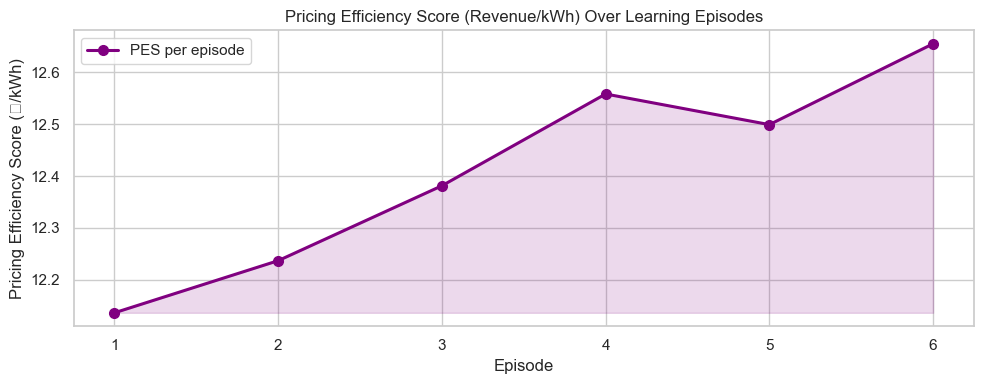

PES start: 12.136  →  PES end: 12.655  (Δ +0.520)


In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monitoring_df['Episode'], monitoring_df['Pricing_Efficiency_Score'],
        marker='o', color='purple', linewidth=2.2, markersize=7, label='PES per episode')
ax.fill_between(monitoring_df['Episode'], monitoring_df['Pricing_Efficiency_Score'],
                monitoring_df['Pricing_Efficiency_Score'].min(),
                alpha=0.15, color='purple')
ax.set_title('Pricing Efficiency Score (Revenue/kWh) Over Learning Episodes')
ax.set_xlabel('Episode')
ax.set_ylabel('Pricing Efficiency Score (₹/kWh)')
ax.set_xticks(monitoring_df['Episode'])
ax.legend()
plt.tight_layout()
plt.show()

pes_start = monitoring_df['Pricing_Efficiency_Score'].iloc[0]
pes_end   = monitoring_df['Pricing_Efficiency_Score'].iloc[-1]
print(f"PES start: {pes_start:.3f}  →  PES end: {pes_end:.3f}  (Δ {pes_end-pes_start:+.3f})")


## Figure — Queue/Wait Time Reduction Over Episodes

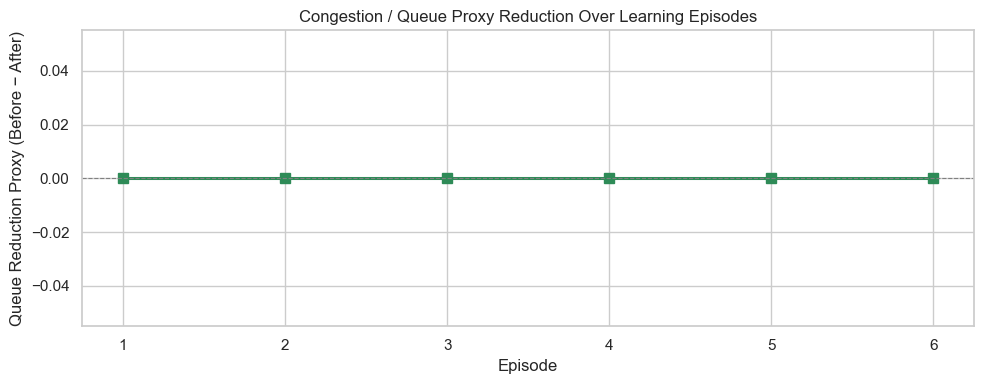

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monitoring_df['Episode'], monitoring_df['Queue_Proxy_Reduction'],
        marker='s', color='seagreen', linewidth=2.2, markersize=7)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Congestion / Queue Proxy Reduction Over Learning Episodes')
ax.set_xlabel('Episode')
ax.set_ylabel('Queue Reduction Proxy (Before − After)')
ax.set_xticks(monitoring_df['Episode'])
plt.tight_layout()
plt.show()


## Figure — Revenue Gain & Off-Peak Uplift Trend

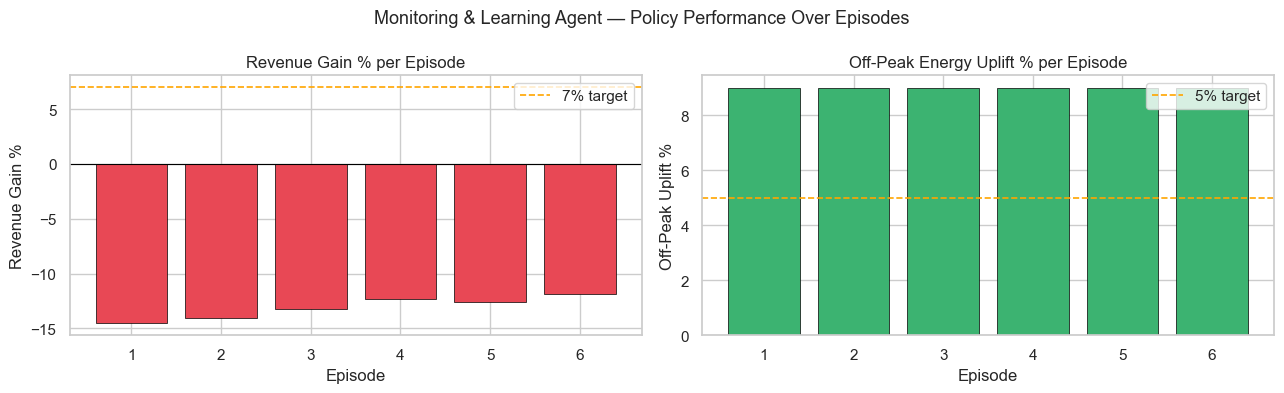

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(monitoring_df['Episode'], monitoring_df['Revenue_Gain_Pct'],
            color=['#E84855' if v < 0 else '#2E86AB' for v in monitoring_df['Revenue_Gain_Pct']],
            edgecolor='black', linewidth=0.5)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].axhline(7, color='orange', linestyle='--', linewidth=1.2, label='7% target')
axes[0].set_title('Revenue Gain % per Episode')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Revenue Gain %')
axes[0].set_xticks(monitoring_df['Episode'])
axes[0].legend()

axes[1].bar(monitoring_df['Episode'], monitoring_df['Off_Peak_Uplift_Pct'],
            color='mediumseagreen', edgecolor='black', linewidth=0.5)
axes[1].axhline(5, color='orange', linestyle='--', linewidth=1.2, label='5% target')
axes[1].set_title('Off-Peak Energy Uplift % per Episode')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Off-Peak Uplift %')
axes[1].set_xticks(monitoring_df['Episode'])
axes[1].legend()

plt.suptitle('Monitoring & Learning Agent — Policy Performance Over Episodes', fontsize=13)
plt.tight_layout()
plt.show()


## Figure — Policy Parameter Evolution

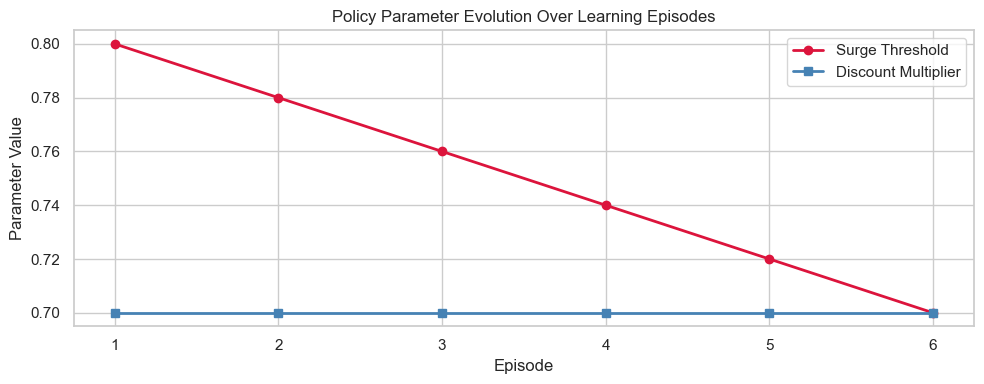


── Final Policy Parameters ──
  Surge threshold  : 0.7000
  Discount mult    : 0.7000


In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monitoring_df['Episode'], monitoring_df['Surge_Threshold'],
        marker='o', color='crimson', linewidth=2, label='Surge Threshold')
ax.plot(monitoring_df['Episode'], monitoring_df['Discount_Multiplier'],
        marker='s', color='steelblue', linewidth=2, label='Discount Multiplier')
ax.set_title('Policy Parameter Evolution Over Learning Episodes')
ax.set_xlabel('Episode')
ax.set_ylabel('Parameter Value')
ax.set_xticks(monitoring_df['Episode'])
ax.legend()
plt.tight_layout()
plt.show()

print("\n── Final Policy Parameters ──")
print(f"  Surge threshold  : {monitoring_df['Surge_Threshold'].iloc[-1]:.4f}")
print(f"  Discount mult    : {monitoring_df['Discount_Multiplier'].iloc[-1]:.4f}")


## Monitoring Summary Table

In [8]:
print("\n" + "="*65)
print("  MONITORING & LEARNING AGENT — FINAL SUMMARY")
print("="*65)
summary_cols = ['Episode','Date','Revenue_Gain_Pct','Pricing_Efficiency_Score',
                'Queue_Proxy_Reduction','Off_Peak_Uplift_Pct','Customer_Response_Rate']
print(monitoring_df[summary_cols].to_string(index=False))
print("="*65)
print(f"\n  Avg Revenue Gain %         : {monitoring_df['Revenue_Gain_Pct'].mean():.2f}%")
print(f"  Avg Pricing Efficiency Score: {monitoring_df['Pricing_Efficiency_Score'].mean():.3f} ₹/kWh")
print(f"  Avg Off-Peak Uplift %       : {monitoring_df['Off_Peak_Uplift_Pct'].mean():.2f}%")
print(f"  Max Queue Reduction         : {monitoring_df['Queue_Proxy_Reduction'].max():.4f}")
print("\n✓ Monitoring & Learning Agent completed.")



  MONITORING & LEARNING AGENT — FINAL SUMMARY
 Episode       Date  Revenue_Gain_Pct  Pricing_Efficiency_Score  Queue_Proxy_Reduction  Off_Peak_Uplift_Pct  Customer_Response_Rate
       1 2022-07-13        -14.543137                 12.135727                    0.0             8.990495                   -30.0
       2 2022-07-14        -14.009948                 12.236426                    0.0             8.997514                   -30.0
       3 2022-07-15        -13.254158                 12.381163                    0.0             8.996568                   -30.0
       4 2022-07-16        -12.316627                 12.558462                    0.0             8.996393                   -30.0
       5 2022-07-17        -12.628636                 12.499282                    0.0             8.996888                   -30.0
       6 2022-07-18        -11.830414                 12.655447                    0.0             8.995807                   -30.0

  Avg Revenue Gain %        